# SEED-OLF Phase 3: Few-Shot Personalization

## tl;dr

- **Classification: `passed`.** P2 passes the full gate at **4 calibration trials** (one per odor).
- At 4 trials, P2 improves held-out Sessions-2/3 log loss by **0.000299** (95% CI **0.000052 to 0.000635**) over the leave-target pooled odor prior.
- The improvement is small but observed for **78.1%** of participants and exceeds all 20 permuted-label controls at each nonzero calibration size.
- Direct target-only estimates and the fixed EEG comparator are worse; pooled shrinkage, not EEG, drives the supported conclusion.


## Methods

Session 1 supplies participant-specific calibration labels. Sessions 2–3 are held out intact. For 4, 8, and 16 trials, each calibration subset is exactly balanced across the four odors and sampled independently of labels. P2 updates a leave-target-participant-out, odor-specific Beta prior. Intervals use a three-level paired bootstrap.

The negative control permutes each participant's Session-1 labels across odors. It retains overall individual response tendency while breaking odor-specific correspondence; therefore the observed effect must exceed its permutation distribution rather than merely exceed zero.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid')
OUTPUT_DIR = Path('artifacts/phase3_fewshot')
summary = pd.read_csv(OUTPUT_DIR / 'prediction_summary.csv')
incremental = pd.read_csv(OUTPUT_DIR / 'incremental_value.csv')
negative = pd.read_csv(OUTPUT_DIR / 'negative_control_summary.csv')
metadata = json.loads((OUTPUT_DIR / 'run_metadata.json').read_text())
validation = json.loads((OUTPUT_DIR / 'validation_checks.json').read_text())


## Primary calibration curve

,calibration_size,candidate,baseline,n_subjects,n_replicates_per_subject,mean_log_loss_improvement,log_loss_ci95_lower,log_loss_ci95_upper,mean_brier_improvement,brier_ci95_lower,brier_ci95_upper,participants_improved_rate,session_2_mean_log_loss_improvement,session_3_mean_log_loss_improvement
4,4,P2,P0,32,200,0.000299,0.000052,0.000635,0.000073,0.000000,0.000149,0.78125,0.000369,0.000230
7,8,P2,P0,32,200,0.000542,0.000148,0.001021,0.000129,0.000016,0.000249,0.78125,0.000677,0.000407
10,16,P2,P0,32,200,0.001118,0.000404,0.001976,0.000269,0.000074,0.000475,0.78125,0.001402,0.000834
13,24,P2,P0,32,1,0.001637,0.000668,0.002847,0.000395,0.000119,0.000688,0.78125,0.002046,0.001228


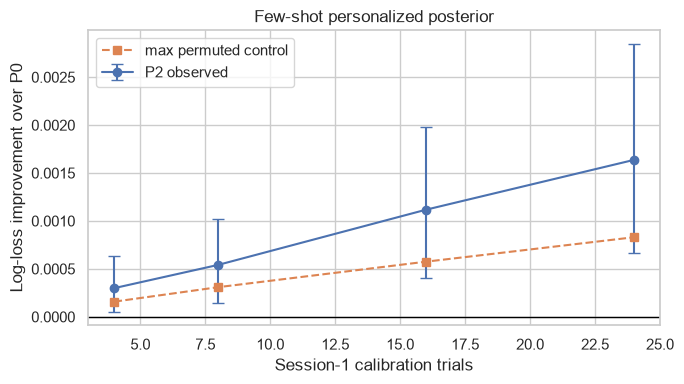

In [2]:
p2 = incremental[incremental.candidate == 'P2'].query('calibration_size > 0').copy()
display(p2.round(6))
fig, ax = plt.subplots(figsize=(7, 4))
errors = [p2.mean_log_loss_improvement - p2.log_loss_ci95_lower, p2.log_loss_ci95_upper - p2.mean_log_loss_improvement]
ax.errorbar(p2.calibration_size, p2.mean_log_loss_improvement, yerr=errors, fmt='o-', capsize=4, label='P2 observed')
null_max = negative[negative.calibration_size > 0].groupby('calibration_size').mean_log_loss_improvement.max()
ax.plot(null_max.index, null_max.values, 's--', label='max permuted control')
ax.axhline(0, color='black', linewidth=1)
ax.set(xlabel='Session-1 calibration trials', ylabel='Log-loss improvement over P0', title='Few-shot personalized posterior')
ax.legend()
plt.tight_layout()
plt.show()


## Comparator and audit checks

In [3]:
display(incremental.query("calibration_size in [4, 24]").round(6))
display(pd.DataFrame(metadata['success_gate']['by_size']).T)
display(pd.Series(validation, name='value').to_frame())


,calibration_size,candidate,baseline,n_subjects,n_replicates_per_subject,mean_log_loss_improvement,log_loss_ci95_lower,log_loss_ci95_upper,mean_brier_improvement,brier_ci95_lower,brier_ci95_upper,participants_improved_rate,session_2_mean_log_loss_improvement,session_3_mean_log_loss_improvement
3,4,P1,P0,32,200,-0.130126,-0.182244,-0.069475,-0.051689,-0.073067,-0.029936,0.06250,-0.133862,-0.126390
4,4,P2,P0,32,200,0.000299,0.000052,0.000635,0.000073,0.000000,0.000149,0.78125,0.000369,0.000230
5,4,P4,P0,32,200,-0.022135,-0.050144,0.005908,-0.007517,-0.018365,0.002991,0.34375,-0.011045,-0.033224
12,24,P1,P0,32,1,-0.020887,-0.074127,0.032457,-0.008985,-0.029341,0.010135,0.46875,-0.008817,-0.032957
13,24,P2,P0,32,1,0.001637,0.000668,0.002847,0.000395,0.000119,0.000688,0.78125,0.002046,0.001228
14,24,P4,P0,32,1,-0.022135,-0.049865,0.006314,-0.007517,-0.017999,0.002936,0.34375,-0.011045,-0.033224


,log_loss_ci_lower_above_zero,brier_point_not_worse,brier_ci_within_margin,majority_of_participants_improve,session_2_nonnegative,session_3_nonnegative,audits_passed,exceeds_permuted_null_maximum
4,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True
16,True,True,True,True,True,True,True,True
24,True,True,True,True,True,True,True,True


,value
status,passed
n_subjects,32
n_trial_prediction_rows,3698688
models,"[P0, P1, P2, P4]"
minimum_feasible_size,4
maximum_metric_recompute_difference,0.0
negative_control_permutations,20


## Takeaways

1. Four odor-balanced labeled trials are enough for a statistically stable, though small, cross-session calibration gain in this public dataset.
2. Direct target-only estimates overfit; empirical-Bayes pooling is essential.
3. The fixed EEG representation adds no value here, so a future deep model must beat P2 under the same grouped and negative-control audits before it is considered useful.
4. Future collection should prospectively reproduce this transparent posterior baseline while treating multimodal physiology as an incremental, not assumed, source of information.
